Status: exploratory

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str((Path("..") / ".." / "src" / "figure4").resolve()))
import blade
import micron_comparison
import visium_hd

plt.rcParams['svg.fonttype'] = 'none'

/tmp/1434790.tinyfat/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths & datasets

MICrONS connectome (row 1) and three 8µm Visium HD samples (rows 2–4),
processed identically and compared side by side.

In [3]:
with open("../../fit_palette.json") as f:
    pal = json.load(f)
BSPBLUE = pal["Piecewise Linear Fit"]

# TODO: point at this checkout's actual MICrONS connectome file — still a
# je30bery-only path, see ../../STORY.md Key Result #4
MICRONS_FN_MAT = "/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/data/reimann_data/microns_mm3_connectome.h5"

SAVE_SVG = "../../result_plots/figure4/figure4_combined.svg"
SAVE_PDF = "../../result_plots/figure4/figure4_combined.pdf"

In [4]:
VISIUM_BASE = "/home/woody/iwbn/iwbn007h/visium_hd_demo_data"
BIN_SIZE_UM = 8.0  # all three datasets are square_008um

VISIUM_DATASETS = [
    {"name": "breast_cancer", "title": "Visium HD 8µm Breast cancer (Fixed Frozen)",
     "h5ad": f"{VISIUM_BASE}/Visium_HD_11mm_Human_Breast_Cancer/breast_cancer_008um_filtered.h5ad"},
    {"name": "colon_cancer_ff", "title": "Visium HD 8µm Colon cancer (Fresh Frozen)",
     "h5ad": f"{VISIUM_BASE}/Visium_HD_11mm_Human_Colon_Cancer_Fresh_Frozen/colon_cancer_ff_008um_filtered.h5ad"},
    {"name": "pancreas", "title": "Visium HD 8µm Pancreas (FFPE)",
     "h5ad": f"{VISIUM_BASE}/Visium_HD_11mm_Human_Pancreas/pancreas_008um_filtered.h5ad"},
]

## Compute

`micron_comparison.prepare_microns_data` (row 1) and `visium_hd.analyze_dataset`
(rows 2–4) do all the loading, tissue-border identification, and BOSPERRUS
fitting — see their docstrings in `src/figure4/` for details.

In [5]:
microns_data = micron_comparison.prepare_microns_data(MICRONS_FN_MAT)
micron_comparison.print_comparison_summary(microns_data["comparison"])

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/figure4/micron_comparison.py:79: RuntimeWarning: invalid value encountered in divide
  C.add_vertex_property("outer_syn_fraction", outer_per_neuron / C.vertices["indegree"].values)


                                 bosperrus  Reimann (neuron)  Reimann (bin)
Neurons affected                    38,777            19,522         36,497
  (% of total)                       65.2%             32.8%          61.4%

Jaccard vs bosperrus
  Reimann per-neuron : 0.500
  Reimann per-bin    : 0.831


In [6]:
visium_results = {cfg["name"]: visium_hd.analyze_dataset(cfg["h5ad"]) for cfg in VISIUM_DATASETS}

INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  


## Summary comparison (Visium HD)

Note on `half_life_frac_of_dmax`: it's deliberately scaled by `d_max` — see
`visium_hd.summarize_fit`'s docstring for why.

In [7]:
summary = pd.DataFrame([
    visium_hd.summarize_fit(cfg["name"], visium_results[cfg["name"]], BIN_SIZE_UM)
    for cfg in VISIUM_DATASETS
])
summary

,dataset,best_fit,effect_strength,half_life_frac_of_dmax,n_bins,elbow_grid_steps,elbow_um,slope_m
0,breast_cancer,Piecewise Linear Fit,-0.100693,0.017059,1458864,14.400056,115.200447,0.074768
1,colon_cancer_ff,Piecewise Linear Fit,-0.070808,0.185664,1720047,193.432246,1547.457964,0.004335
2,pancreas,Piecewise Linear Fit,-0.112076,0.006369,1246205,3.881400,31.051201,0.382449


## BLADE comparison

`blade.peel_sweep` (see `src/figure4/blade.py`) peels grid-NN<4 border layers
one at a time and Welch-t-tests each layer against the remaining interior,
for both raw and BOSPERRUS-corrected counts.

In [8]:
blade_results = {
    cfg["name"]: visium_hd.blade_comparison(visium_results[cfg["name"]])
    for cfg in VISIUM_DATASETS
}

comparison_table = pd.DataFrame([
    {"dataset": name, "counts": label, "blade_buffer": buffer}
    for name, (_, buffers) in blade_results.items()
    for label, buffer in buffers.items()
]).pivot_table(index="dataset", columns="counts", values="blade_buffer")
comparison_table

counts,bosperrus_corrected,raw
dataset,,
breast_cancer,12.0,54.0
colon_cancer_ff,7.0,172.0
pancreas,14.0,14.0


## Combined figure (4 rows × 3 columns)

Row 1: MICrONS (degree-only fit, gray points / bspblue fit; boundary heatmap
as-is, spanning cols 2–3). Row 2: Visium counts vs. distance to tissue border.
Row 3: Visium decision-boundary overlay (bspblue exclusion, magma counts).
Row 4: BLADE peel comparison (raw = magenta, bosperrus-corrected = bspblue).

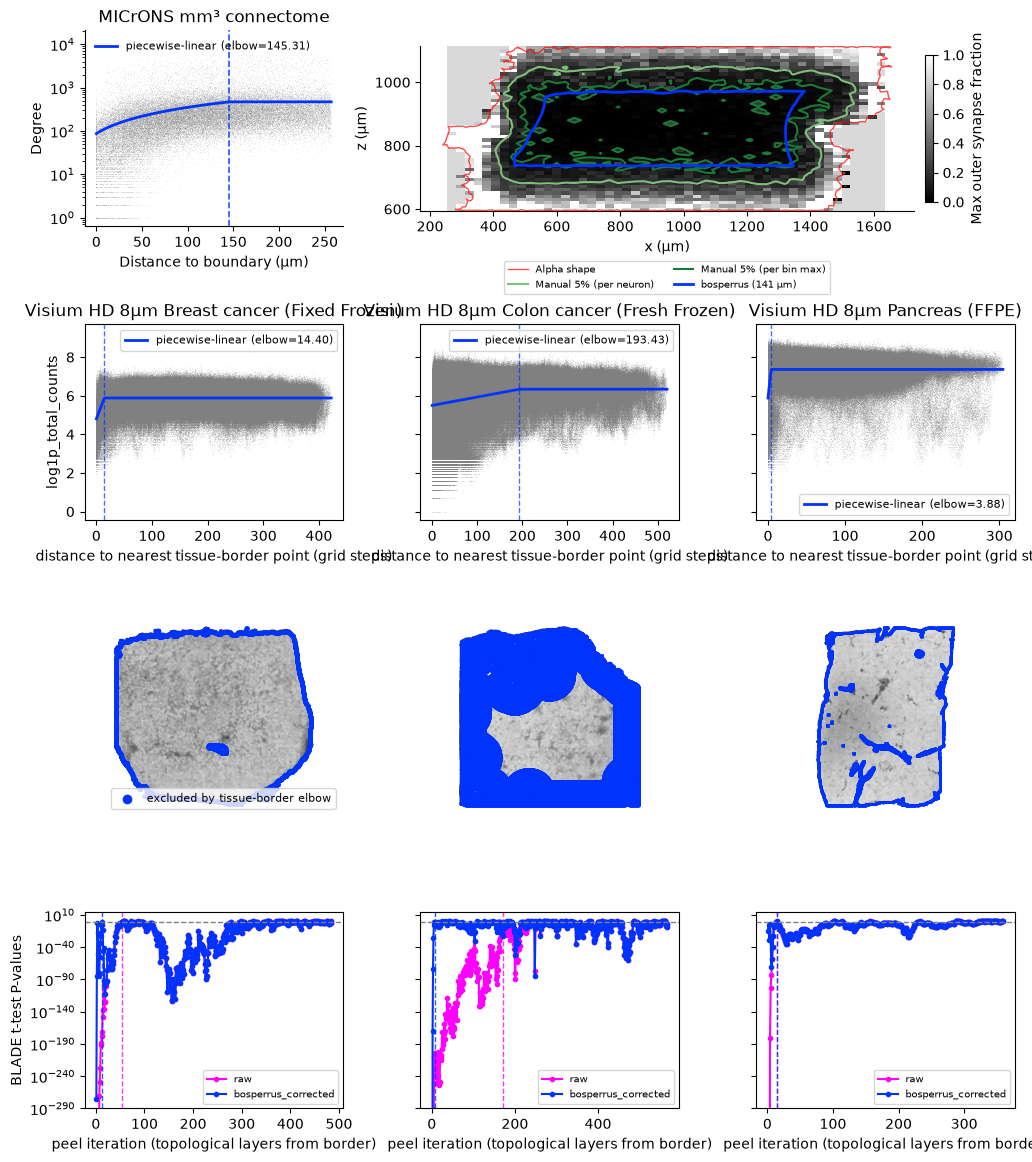

In [11]:
fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3)

# unified scatter params for the row 1 / row 2 fit panels
SCATTER_SIZE, SCATTER_ALPHA, SCATTER_LINEWIDTHS = 0.3, 0.1, 0

# Row 1 — MICrONS: degree-only fit, plus the boundary heatmap "as is" (spanning cols 2-3)
ax_fit = fig.add_subplot(gs[0, 0])
micron_comparison.plot_fits_panel(
    ax_fit, microns_data["flow"], microns_data["alpha_distances"], microns_data["scores"],
    measures=["degree"], scatter_color="gray", fit_color=BSPBLUE,
    legend_label_fn=lambda measure, b, m, c: f"piecewise-linear (elbow={b/1e3:.2f})",
    ylabel="Degree",
    title="MICrONS mm³ connectome",
    scatter_size=SCATTER_SIZE, scatter_alpha=SCATTER_ALPHA, scatter_linewidths=SCATTER_LINEWIDTHS,
)

ax_heatmap = fig.add_subplot(gs[0, 1:])
micron_comparison.plot_boundary_heatmap_panel(
    ax_heatmap, microns_data,
    cmap="gray",
    boundary_label="Alpha shape", boundary_color="red",
    reimann_neuron_label="Manual 5% (per neuron)", reimann_neuron_color="#7FBF7B",
    reimann_bin_label="Manual 5% (per bin max)", reimann_bin_color="#1B7837",
    legend_bbox_to_anchor=(0.5, -0.3),
)

# Row 2 — Visium: counts vs. distance to tissue-border points (NN<4). Shared y
# across the row (same measure for all 3 datasets); only col 0 keeps the label.
ax_row2_0 = None
for col, cfg in enumerate(VISIUM_DATASETS):
    ax = fig.add_subplot(gs[1, col], sharey=ax_row2_0)
    ax_row2_0 = ax_row2_0 or ax
    visium_hd.plot_counts_vs_distance(
        ax, visium_results[cfg["name"]], fit_color=BSPBLUE, title=cfg["title"],
        ylabel=None if col == 0 else "",
        scatter_size=SCATTER_SIZE, scatter_alpha=SCATTER_ALPHA, scatter_linewidths=SCATTER_LINEWIDTHS,
    )
    if col > 0:
        plt.setp(ax.get_yticklabels(), visible=False)

# Row 3 — Visium: decision boundary overlay (bspblue exclusion, gray counts).
# Titles are shared with row 2 (same 3 datasets, same column order), so we
# skip them here and on row 4.
for col, cfg in enumerate(VISIUM_DATASETS):
    ax = fig.add_subplot(gs[2, col])
    visium_hd.plot_decision_boundary(
        ax, visium_results[cfg["name"]], cmap="gray", boundary_color=BSPBLUE,
        boundary_alpha=0.3, add_legend=(col == 0),
    )

# Row 4 — BLADE peel comparison (raw = magenta, bosperrus-corrected = bspblue).
# Shared y across the row (both are p-values on the same 0-1 scale). Welch
# t-tests on these huge samples routinely underflow to p ~ 1e-50 or smaller,
# which would otherwise stretch the axis and squash the region near alpha=0.05
# — ylim_bottom crops those out of view (they're still in sweep_df, just not drawn).
BLADE_YLIM_BOTTOM = 1e-290
blade_colors = {"raw": "magenta", "bosperrus_corrected": BSPBLUE}
ax_row4_0 = None
for col, cfg in enumerate(VISIUM_DATASETS):
    ax = fig.add_subplot(gs[3, col], sharey=ax_row4_0)
    ax_row4_0 = ax_row4_0 or ax
    sweep_df, _ = blade_results[cfg["name"]]
    blade.plot_peel_sweep(ax, sweep_df, ["raw", "bosperrus_corrected"], blade_colors,
                           ylabel="BLADE t-test P-values" if col == 0 else None,
                           ylim_bottom=BLADE_YLIM_BOTTOM)
    if col > 0:
        plt.setp(ax.get_yticklabels(), visible=False)

os.makedirs(os.path.dirname(SAVE_SVG), exist_ok=True)
fig.savefig(SAVE_SVG, bbox_inches="tight")
#fig.savefig(SAVE_PDF, bbox_inches="tight")
plt.show()